In [1]:
import os
import math
import sys
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
from tqdm import trange, tqdm
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import torch.nn.functional as F  
from torch.utils.tensorboard import SummaryWriter

from Utils.CADTensorGenerator import CADTensorGenerator
from Utils.CADVisualizer   import CADVisualizer
from HDVClassNet.PP_net import PPNet
from HDVClassNet.VoronoiDecorder import VoronoiDecoder
from Training.MainTrain import TrainingConfig, NN_Trainer
from neuraltomo_fem import run_fem_loss
from problems.ThickenShell import ThickenShell

import pyvista as pv


# ---- Reproducibility (recommended for D_params comparisons) ----
SEED = 20
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

BASE = Path(__file__).parent if "__file__" in globals() else Path.cwd()
print("Code Directory:", BASE)
TesPartsDir = BASE / "Testparts" 
print("Test Step files Directory:", TesPartsDir)


if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("device:", device)
# -------- PYVISTA BACKEND --------
def setup_pyvista(device):
    is_mac = sys.platform == "darwin"

    # Mac + MPS: prefer static to avoid VTK/trame hangs
    if is_mac :
        pv.OFF_SCREEN = True
        pv.set_jupyter_backend("static")
        backend = "static"
    else:
        try:
            pv.set_jupyter_backend("trame")
            backend = "trame"
        except Exception:
            pv.OFF_SCREEN = True
            pv.set_jupyter_backend("static")
            backend = "static"

    print(f"PyVista backend: {backend}")

setup_pyvista(device)


gmesh was loaded successfully!
Code Directory: /home/arash/HDV_Shell
Test Step files Directory: /home/arash/HDV_Shell/Testparts
device: cuda
PyVista backend: trame


In [3]:
viz = CADVisualizer()
# Laoding model and extracting mesh and tensors as input
FreeFormSurf1  = TesPartsDir / "FreeFormCrv1.stp"
FreeFormSurf2A = TesPartsDir / "FreeFormSurf2A.STEP"
YachtBodypart  = TesPartsDir / "YachtBodypart.stp"
CircularSurf1  = TesPartsDir / "CircularSurf1.stp"
Cube           = TesPartsDir / "Cube.stp"
CircularSur2   = TesPartsDir / "CircularSur2.stp"
Conic          = TesPartsDir / "Conic.stp"
CircularHoles  = TesPartsDir / "CircularHoles.stp"
FullCylinder   = TesPartsDir / "FullCylinder.stp"
Sphere         = TesPartsDir / "Sphere.stp"
SphereTap      = TesPartsDir / "SphereTap.stp"
Tidebottle     = TesPartsDir / "Tidebottle.STEP"


shape_path = FreeFormSurf1

# Meshing controls
# OCC meshing (global fallback for mode="mesh"):
#   - deflection: smaller -> finer OCC mesh
#   - angle: smaller -> finer OCC mesh on curved regions
# Manual UV-grid meshing (used when freeform_mesher="manual" on supported analytic faces):
#   - n_u, n_v: more samples -> finer UV grid mesh
# Gmsh meshing (used for free-form faces when freeform_mesher is "auto" or "gmsh"):
#   - gmsh_size_scale: smaller -> finer mesh, larger -> coarser mesh
#   - gmsh_algorithm: picks the Gmsh 2D meshing algorithm (6 is a solid default)
# Mesher selection:
#   - freeform_mesher="auto": try Gmsh first, then fall back to OpenCascade
#   - freeform_mesher="gmsh": require Gmsh for free-form faces
#   - freeform_mesher="manual": use UV-grid on supported analytic faces, otherwise OpenCascade

Case_name = shape_path.stem
print(Case_name)
generator = CADTensorGenerator(
    deflection=0.001,
    angle=0.001,
    metric_tol=1e-9,
    det_min=1e-5,
    n_u=100,
    n_v=100,
    freeform_mesher="auto",
    gmsh_size_scale=1.0,
    gmsh_algorithm=6,
    device=device,
)

mesh_df, faces_df, tensors = generator.generate_from_file(
    shape_path=str(shape_path),
    input_ring=1,
    mode="mesh", #"1: mesh" "2:Sampled_points "
    M_per_face=2000,
    pool_size_factor=10,
    fps_pool_factor=4,
    use_fps=True,
    triangulation_max_edge_rel=0.1,
)

uv = tensors["uv"]
points_xyz = tensors["points_xyz"]
uv = tensors["uv"]
Xu = tensors["Xu"]
Xv = tensors["Xv"]
points_xyz = tensors["points_xyz"]
face_areas = tensors["face_areas"]
faces_ijk = tensors["faces_ijk"]
face_id = tensors["face_id"]
boundary_idx_ring1 = tensors["boundary_idx_ring1"]
pv_faces = tensors["pv_faces"]
bbx_all = list(tensors["BBX"].values())



xmin = min(b["xmin"] for b in bbx_all)
xmax = max(b["xmax"] for b in bbx_all)
ymin = min(b["ymin"] for b in bbx_all)
ymax = max(b["ymax"] for b in bbx_all)
zmin = min(b["zmin"] for b in bbx_all)
zmax = max(b["zmax"] for b in bbx_all)

dx = xmax - xmin
dy = ymax - ymin
dz = zmax - zmin


print(f"Number of faces: {tensors['num_faces']}")
print(f"Number of Sampled points: {uv.shape[0]}")
print(f"Global BBX dimensions: dx={dx:.4f}, dy={dy:.4f}, dz={dz:.4f}")

# Visualization follows the selected mesh path because it uses the returned
# `points_xyz` and `pv_faces` tensors directly.
# Increase visual resolution by changing the meshing parameters above:
#   - mode="mesh" + OCC: decrease deflection / angle
#   - mode="mesh" + manual UV: increase n_u / n_v
#   - mode="mesh" + Gmsh: decrease gmsh_size_scale
#   - mode="Sampled_points": increase M_per_face and optionally reduce
#     triangulation_max_edge_rel
viz.visualize_show_Model(points_xyz, pv_faces)


pts = points_xyz.detach().cpu().numpy()
cloud = pv.PolyData(pts)
plotter = pv.Plotter()
plotter.add_mesh(cloud, render_points_as_spheres=True, point_size=6)
plotter.show()

FreeFormCrv1
Model is meshed using Gmsh tool
MinVolFrac: 0.05036073550581932
Number of faces: 1
Number of Sampled points: 12385
Global BBX dimensions: dx=6.1138, dy=6.5514, dz=2.6732


Widget(value='<iframe src="http://localhost:34133/index.html?ui=P_0x766611c4ebf0_2&reconnect=auto" class="pyvi…

Widget(value='<iframe src="http://localhost:34133/index.html?ui=P_0x7665f4c1d1e0_3&reconnect=auto" class="pyvi…

In [4]:
fixed_height_shell= 0.2
# shell_problem = ThickenShell(
#     thickness=fixed_height_shell,
#     BC_dir = "y",
#     Load_magnitude=0.0001,
#     voxel_size=0.1,
#     extra_layers=1,
#     tensors=tensors,
#     tangential_tol=0.1,
# )
shell_problem =None
fem =None
# fem = run_fem_loss.NeuralTOMOFEM(shell_problem, device=device, isotropic=False)
# shell_problem.debug_voxel_stats()
# shell_problem.show_voxels_surface_and_bc()

In [5]:
cfg = TrainingConfig(
    # ============================================================
    # Seed / geometry setup
    # ============================================================
    seed_number=10,
    use_Metric_anisotropy=False,
    fixed_height=fixed_height_shell,
    freeze_w=False,
    w_min=0.0005,
    # Pairwise strut widths now use w_max_ij = 0.8 * seed_distance(i, j).
    use_boundary_attachment=True,
    boundary_vol_weight = 0.5,
    use_boundary_weighted_volume=False,


    # fallback / initialization ranges used by decoder maps
    boundary_attach_alpha = 1.0,
    boundary_attach_width = 0.01,
    boundary_attach_beta = 0.005,

    boundary_attach_width_min=05e-6,
    boundary_attach_width_max=5e-5,

    # PPNet predicts these now
    predict_pair_gating=True,
    predict_boundary_width=True,

    # pair-gating bounds/defaults
    gap_thr_min=0.00,
    gap_thr_max=0.50,
    big_thr_min=0.00,
    big_thr_max=0.60,
    alpha_min=0.01,
    alpha_max=0.20,
    eta_min=0.01,
    eta_max=0.20,

    gap_thr_default=0.15,
    big_thr_default=0.10,
    alpha_default=0.05,
    eta_default=0.05,

    # ============================================================
    # Main geometric / physical target
    # ============================================================
    target_volfrac=0.2,

    # ============================================================
    # Geometric regularization terms
    # ============================================================
    seed_repulsion_sigma=0.08,
    boundary_margin=0.05,

    # ============================================================
    # Core loss weights
    # ============================================================
    lam_fem=0.0,
    lam_vol=20.0,
    lam_rep=0.015,
    lam_bnd=0.0,
    lam_strut=0.0005,
    lam_strut_edge=0.0,
    lam_strut_void=0.2,

    # ============================================================
    # Gate losses
    # ============================================================
    use_gating=False,
    lam_gate_count=0.005,
    lam_gate_binary=0.1,
    gate_target_count=10.0,
    gate_warmup_steps=20,
    gate_binary_warmup_steps=80,
    gate_sharpen_gamma=2.0,
    gate_active_threshold=0.3,
    gate_eps=1e-8,
    gate_bias_init=2.0,

    # ============================================================
    # Learning rates
    # ============================================================
    lr_seed_refine=0.003,
    lr_delta_head=1e-4,
    lr_mlp=2e-4,
    lr_w_head=2e-3,
    lr_h_head=2e-4,
    lr_gate_head=5e-5,
    lr_pair_heads=2e-4,
    lr_boundary_heads=5e-4,

    # ============================================================
    # FEM / normalization
    # ============================================================
    comp_normalize_by=None,
    normalize_losses=False,
    fem_density_floor=0.02,
    skip_bad_fem_steps=True,

    # ============================================================
    # Optimization schedule
    # ============================================================
    num_steps=1000,
    context_vector_size=8,
    log_every=100,
    early_stop_start=5000,
    patience=5000,
    min_delta=1e-10,

    # ============================================================
    # Decoder softness / geometry shaping
    # ============================================================
    tau=0.1,
    beta=0.02,

    # ============================================================
    # Scheduler / training stability
    # ============================================================
    scheduler_milestones=(0.9,),
    scheduler_gamma=0.2,
    Offset_scale=5,
    save_fem_debug_history=True,
    grad_clip_norm=1.0,

    # ============================================================
    # TensorBoard logging
    # ============================================================
    experiment_name=str(Case_name),
    tensorboard_enabled=True,
    tb_log_histograms_every=100,

    # ============================================================
    # Timelapse / visualization
    # ============================================================
    MakeTimelaps=True,
    timelapse_frame_step=10,
    TM_laps_res_u=150,
    TM_laps_res_v=150,
    TM_laps_Thr=0.25,
)

trainer = NN_Trainer(
    generator=generator,
    viz=viz,
    decoder_cls=VoronoiDecoder,
    ppnet_cls=PPNet,
    fem=fem,
    shell_problem=shell_problem,
    config=cfg,
)

print(cfg)

result = trainer.train(
    shape_path,
    face_tensors=tensors["face_tensors"],
)

TensorBoard log dir: runs/FreeFormCrv1
TrainingConfig(seed_number=10, use_Metric_anisotropy=False, fixed_height=0.2, target_volfrac=0.2, seed_repulsion_sigma=0.08, boundary_margin=0.05, freeze_w=False, use_boundary_attachment=True, boundary_volume_assist=0.1, boundary_attach_width=0.01, boundary_attach_beta=0.005, boundary_attach_alpha=1.0, boundary_attach_width_min=5e-06, boundary_attach_width_max=5e-05, boundary_attach_alpha_min=0.05, boundary_attach_alpha_max=1.0, boundary_attach_beta_min=0.003, boundary_attach_beta_max=0.05, gap_thr_min=0.0, gap_thr_max=0.5, big_thr_min=0.0, big_thr_max=0.6, alpha_min=0.01, alpha_max=0.2, eta_min=0.01, eta_max=0.2, gap_thr_default=0.15, big_thr_default=0.1, alpha_default=0.05, eta_default=0.05, gate_sharpen_gamma=2.0, w_min=0.0005, w_max=0.5, lam_fem=0.0, lam_vol=20.0, lam_rep=0.015, lam_bnd=0.0, lam_strut=0.0005, lam_strut_edge=0.0, lam_strut_void=0.2, comp_normalize_by=None, normalize_losses=False, fem_density_floor=0.02, skip_bad_fem_steps=True,

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

New best_step=0 | best_score=0.296942 | vol_eff=0.049243 | comp=0.000000e+00 | w=2.750618e-01
[00000] | active(total/mean)=0/0.00 | gate(min/mean/max)=0.000/0.000/0.000 | L_total=2.9694e-01 | L_vol=1.485e-02 L_fem=0.000e+00 L_strut=0.000e+00 L_rep=5.383e-05 L_bnd=5.387e-01 L_gate=0.000e+00 L_gbin=0.000e+00 | vol=0.269 vol_eff=0.049 (/0.200) comp=0.000e+00 | w=2.751e-01 h=2.000e-01 | gap=2.593e-01 big=3.048e-01 alpha=1.037e-01 eta=1.078e-01 | bw=2.830e-05 ba=1.000e+00 bb=5.000e-03 | theta=0.000e+00 a=0.000e+00 | Lse=7.608e-01 Lsv=0.000e+00 | rho(min/mean/max)=0.000/0.286/0.999 rho_b(min/mean/max)=0.000/0.159/0.998 rho_v(min/mean/max)=0.000/0.144/0.628 | Δrho=0.00e+00 Δseed=0.00e+00 grad_mean=3.05e-02 | fem=OK | best=2.9694e-01@0
[00100] | active(total/mean)=0/0.00 | gate(min/mean/max)=0.000/0.000/0.000 | L_total=1.1994e-01 | L_vol=5.997e-03 L_fem=0.000e+00 L_strut=0.000e+00 L_rep=9.373e-06 L_bnd=5.560e-01 L_gate=0.000e+00 L_gbin=0.000e+00 | vol=0.339 vol_eff=0.114 (/0.200) comp=0.000e+0

In [6]:
trainer.visualize_result_stepwise(result, points_xyz, faces_ijk)
trainer.visualize_result_final(result, points_xyz, faces_ijk, thr=0.5, show_solid=False)

Widget(value='<iframe src="http://localhost:34133/index.html?ui=P_0x766932b77a60_4&reconnect=auto" class="pyvi…

threshold=0.5 (manual) | solid%=37.901%


Widget(value='<iframe src="http://localhost:34133/index.html?ui=P_0x766932b74b80_5&reconnect=auto" class="pyvi…

(UnstructuredGrid (0x7663621fb3a0)
   N Cells:    10084
   N Points:   5795
   X Bounds:   -3.114e+00, 3.000e+00
   Y Bounds:   -2.136e+00, 4.416e+00
   Z Bounds:   1.266e-02, 2.686e+00
   N Arrays:   3,
 0.5)

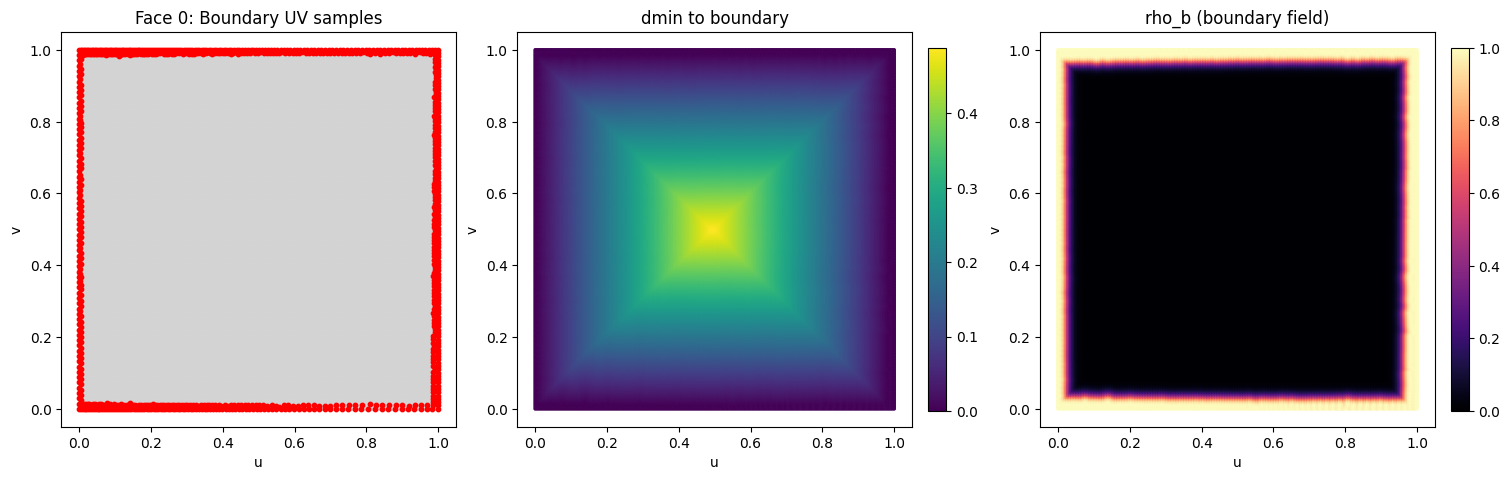

[Face 0] boundary_pts=851 | dmin(min/mean/max)=(0.000e+00/1.568e-01/4.884e-01) | rho_b(min/mean/max)=(0.000e+00/1.411e-01/9.982e-01) | grid=(220 x 220)


In [7]:
# Increase `dense_factor` for denser UV debug sampling.
dbg = trainer.visualize_boundary_attachment_debug(
    result=result,
    shape_or_path=str(shape_path),
    face_index=0,      # change if needed
    grid_res_u=220,
    grid_res_v=220,
    dense_factor=1.0,
)


In [9]:
# Increase `dense_factor` to get a denser smooth point visualization.
smooth = trainer.visualize_result_final_smooth_points(
    result=result,
    shape_or_path=str(shape_path),
    thr=0.1,
    grid_res_u=300,
    grid_res_v=300,
    dense_factor=2.0,
)

Smooth CAD-native visualization: kept 163855 / 360000 dense points with threshold 0.100 on grid (600 x 600)


Widget(value='<iframe src="http://localhost:34133/index.html?ui=P_0x7663621a8fa0_7&reconnect=auto" class="pyvi…

In [ ]:
trainer.visualize_best_seed_activity(result, points_xyz, faces_ijk)
print(result["tensorboard_log_dir"])

In [11]:
# Increase `dense_factor` to refine the CAD-native smooth surface display.
out = trainer.visualize_result_final_smooth_surface_pyvista(
    result=result,
    shape_or_path=str(shape_path),
    thr=0.55,
    grid_res_u=300,
    grid_res_v=300,
    dense_factor=2.0,
)
print(out["thr_used"], out["volfrac_thr"])

[smooth_surface] thr=0.5500 | volfrac_cont(rho)=0.3303 | volfrac_thr(binary)=0.3570 | target=0.2000 | grid=(600 x 600)


Widget(value='<iframe src="http://localhost:34133/index.html?ui=P_0x7663621d0d90_9&reconnect=auto" class="pyvi…

0.55 0.35702210664749146


In [ ]:
for t in [0.01,0.05,0.1,0.15,0.25,0.35,0.45,0.5]:    
    out = trainer.visualize_result_final_smooth_surface_pyvista(
        result=result,
        shape_or_path=str(shape_path),
        thr=t ,
        grid_res_u=300,
        grid_res_v=300,
        dense_factor=1.0,
    )
    print(out["thr_used"], out["volfrac_thr"])



In [ ]:
%load_ext tensorboard
%tensorboard --logdir runs